# Malli 2: Esikoulutettu malli piirteenirrottajana

Tässä notebookissa toteutetaan Malli 2, jossa käytetään esikoulutettua
VGG16-konvoluutioneuroverkkoa piirteiden irrottamiseen (feature extraction).
VGG16:n painot pidetään jäädytettyinä, ja vain oma luokittelupää koulutetaan
omalla datasetillä.

In [1]:
import keras
from keras import layers
from keras.utils import image_dataset_from_directory
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input

In [2]:
train_dataset = image_dataset_from_directory(
    "./dataset_split/train",
    image_size=(224, 224),
    batch_size=32
)

validation_dataset = image_dataset_from_directory(
    "./dataset_split/validation",
    image_size=(224, 224),
    batch_size=32
)

test_dataset = image_dataset_from_directory(
    "./dataset_split/test",
    image_size=(224, 224),
    batch_size=32
)

class_names = train_dataset.class_names
num_classes = len(class_names)

print("Luokat:", class_names)
print("Luokkien määrä:", num_classes)

Found 105 files belonging to 3 classes.
Found 21 files belonging to 3 classes.
Found 24 files belonging to 3 classes.
Luokat: ['autot', 'laivat', 'lentokoneet']
Luokkien määrä: 3


In [3]:
conv_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

conv_base.trainable = False


In [4]:
def preprocess(images, labels):
    return preprocess_input(images), labels

train_vgg = train_dataset.map(preprocess)
val_vgg = validation_dataset.map(preprocess)
test_vgg = test_dataset.map(preprocess)

In [5]:
inputs = keras.Input(shape=(224, 224, 3))

x = conv_base(inputs)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       1,605,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,320,579 (62.26 MB)

 Trainable params: 1,605,891 (6.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Luokittelupäässä käytettiin 64 neuronia ja Dropout-arvoa 0.3, koska
datasetin koko oli pieni. Lisäksi koulutus rajoitettiin viiteen
epochiin, sillä malli konvergoi nopeasti esikoulutetun VGG16-mallin
ansiosta. Näillä valinnoilla pyrittiin vähentämään ylisovitusta ja
parantamaan mallin yleistettävyyttä.

In [6]:
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="model2_feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

history = model.fit(
    train_vgg,
    epochs=5,
    validation_data=val_vgg,
    callbacks=callbacks
)

Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6762 - loss: 12.2145 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9905 - loss: 0.2485 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 1.0000 - loss: 3.2211e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


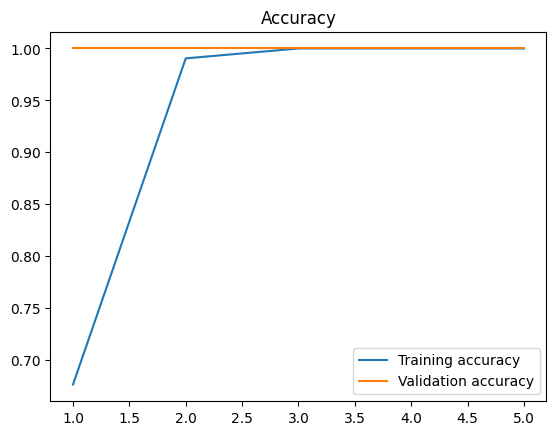

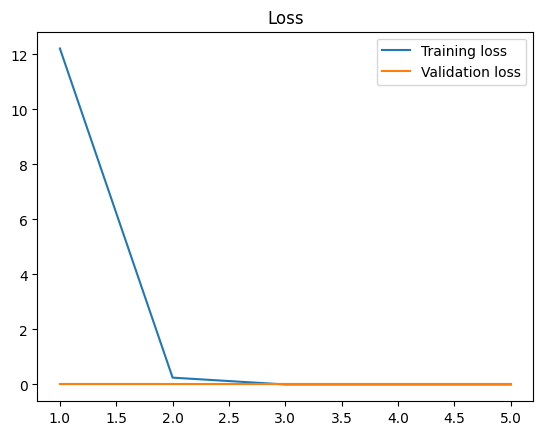

In [7]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.legend()
plt.title("Loss")
plt.show()

In [8]:
test_model = keras.models.load_model("model2_feature_extraction.keras")

test_loss, test_acc = test_model.evaluate(test_vgg)

print(f"Malli 2 test accuracy: {test_acc:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9583 - loss: 4.6268
Malli 2 test accuracy: 0.958


## Analyysi

Malli 2 saavutti täydellisen tarkkuuden validointidatalla. Tämä johtuu
datasetin pienestä koosta (validointisetti sisälsi vain 21 kuvaa) sekä siitä,
että käytetty VGG16-malli on esikoulutettu laajalla ImageNet-datalla ja pystyy
erottamaan luokat helposti. Tästä syystä testidatan tulokset ovat luotettavampi
mittari mallin yleistymiskyvylle.